In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

m = [109, 65, 26]
n = 200

### Оценка лямбды методом ОМПГ (Численный поиск максимума)

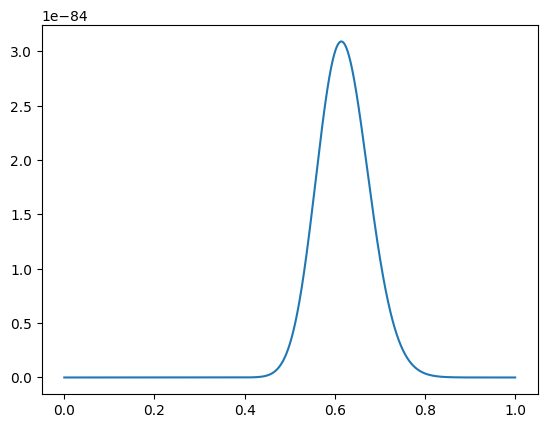

Оценка лямбды: 0.6144614461446145


In [49]:
def L(lambda_: np.array):
    l = (np.exp(-lambda_)**109)*((lambda_*np.exp(-lambda_))**65)*((1-np.exp(-lambda_)-(lambda_*np.exp(-lambda_)))**26)
    return l

x = np.linspace(0, 1, 10000)
L_x = L(x)

figure, axis = plt.subplots()
axis.plot(x, L_x)
plt.show()

lambda_est = x[np.argmax(L_x)]
print(f"Оценка лямбды: {lambda_est}")



### Расчёт дельты (Меры расхождения)

In [50]:
def p_i(x: int, lambda_: float):
    if x == 0:
        return np.exp(-lambda_)
    elif x == 1:
        return (lambda_**x) * (np.exp(-lambda_))
    elif x == 2:
        return 1 - (np.exp(-lambda_)) - (lambda_ * (np.exp(-lambda_)))

def count_delta():
    result = 0
    for i in range(3):
        p = p_i(i, lambda_est)
        if p > 0:
            result += ((m[i] - n * p) **2) / (n * p)
    return result

delta = count_delta()
print(delta)

0.0562467470913659


### Расчёт p-value

In [51]:
p_value = 1 - chi2.cdf(delta, 1)
print(p_value)

0.8125295893292737
